In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import envelope
from scipy.signal import find_peaks
import librosa
from matplotlib.patches import Rectangle
from scipy.fft import fft, fftfreq
import glob

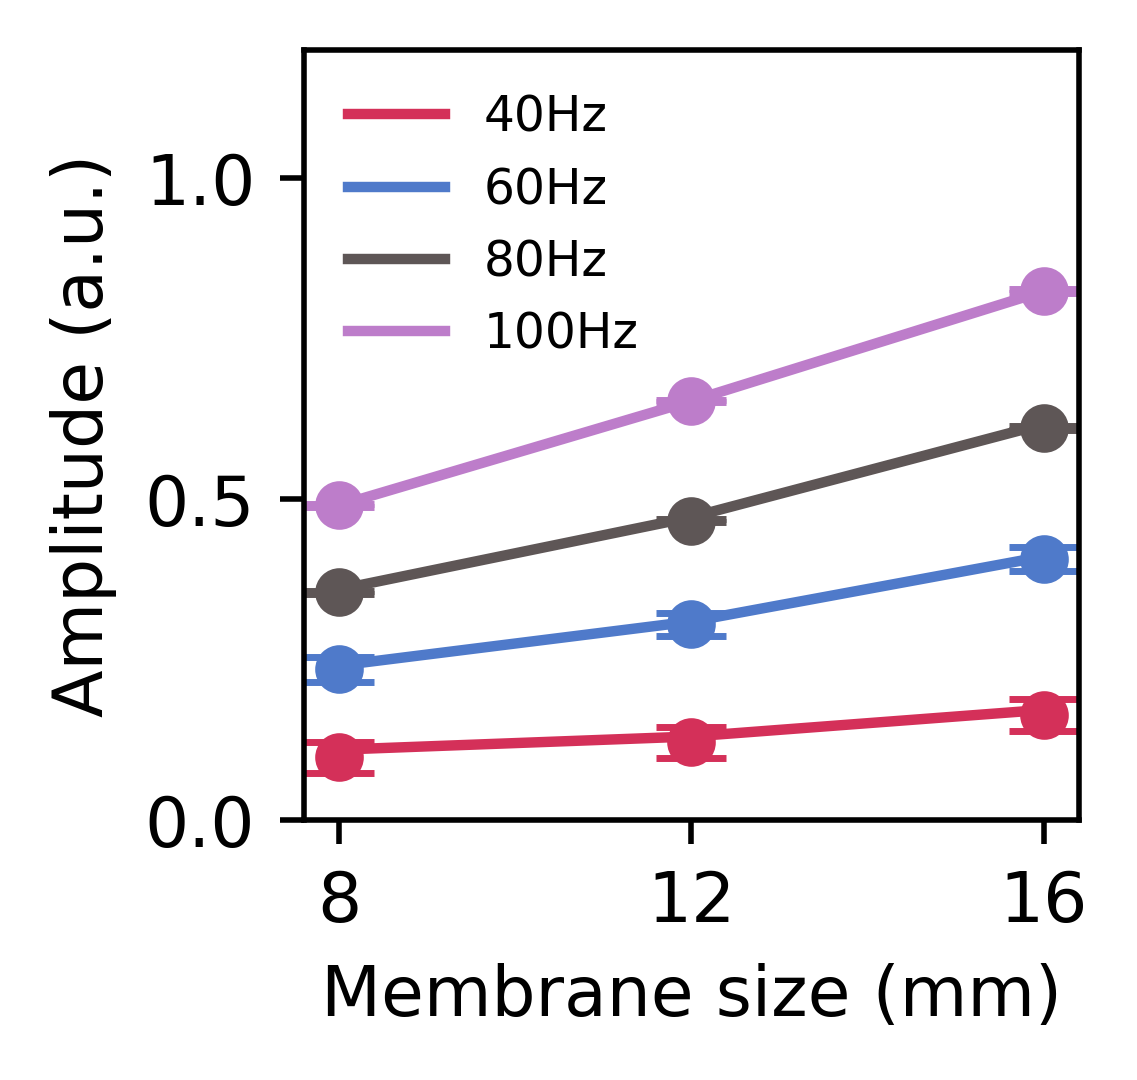

In [2]:
plt.figure(figsize=[2, 2], dpi=500)
plt.xticks([8, 12, 16])
plt.ylim([0, 1.2])
col = ["#D43059", "#4F7ACA", "#5E5656", "#BD7DCA"]
D_df = pd.read_csv('Fig3h_data.csv')
normed = []

for i in [8, 12, 16]:
    for j in np.linspace(20, 200, 10):
        ref = D_df[(D_df['Membrane size (mm)'] == 0) & (D_df['Frequency (Hz)'] == j)]
        target = D_df[(D_df['Membrane size (mm)'] == i) & (D_df['Frequency (Hz)'] == j)]
        if not ref.empty and not target.empty:
            norm_amp = target['Amplitude (a.u.)'].values[0] 
            normed.append({'Membrane size (mm)': i, 'Frequency (Hz)': j, 'norm_signal': norm_amp})

normed_df = pd.DataFrame(normed)

for i in [40, 60, 80, 100]:
    subset = normed_df[normed_df['Frequency (Hz)'] == i]
    plt.plot(subset['Membrane size (mm)'], subset['norm_signal']/3, label=f'{i}Hz', color=col[int(i/20)-2])

for file in glob.glob(f'B*/*.csv'):   
    fs = 3125
    a = np.array(pd.read_csv(file, skiprows=16))[:, 1]
    a = np.squeeze(a)
    msize = int(str(file).split('\\')[0].replace('B', ''))
    fx = int(int(str(file).split('\\')[1].split('.')[0].replace('TEK000', ''))/2) * 20 + 20
    index = int(str(file).split('\\')[1].split('.')[0].replace('TEK000', ''))%2
    if index == 0:
        sos = signal.butter(2, [fx-5, fx+5], 'bandpass', fs=fs, output='sos')
        f = signal.sosfilt(sos, a[:])[1000:-100]
        f = f - np.mean(f) 
        p, _ = find_peaks(f, prominence=0.02, width=1)
        amplitude = np.std(f)*1.41
        if msize>0 and fx in [40, 60, 80, 100]:
            plt.errorbar(msize, amplitude/3, np.std(f[p])/3, color=col[int(fx/20)-2], ls='', marker='o', capsize=5, capthick=1)

plt.locator_params(axis='x', nbins=4)
plt.locator_params(axis='y', nbins=4)
plt.legend(frameon=False, loc='upper left', fontsize=7)
# plt.grid(True)
plt.xlabel('Membrane size (mm)')
plt.ylabel('Amplitude (a.u.)')
plt.show()
